In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Data_for_UCI_named.csv")
print("Veri yüklendi!")
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
df.head()

Veri yüklendi!
Satır sayısı: 10000
Sütun sayısı: 14


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [14]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [15]:
# Hedef sütunumuzun dağılımı
print(df['stabf'].value_counts())

stabf
unstable    6380
stable      3620
Name: count, dtype: int64


/tmp/ipykernel_12015/3820400385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stabf', data=df, palette='Set2')


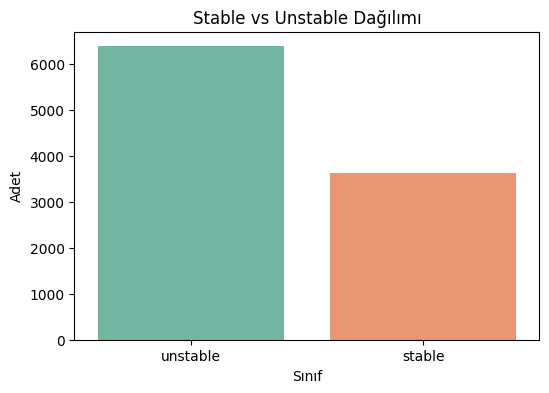

In [17]:
# Sınıf dağılımını görselleştirelim
plt.figure(figsize=(6,4))
sns.countplot(x='stabf', data=df, palette='Set2')
plt.title('Stable vs Unstable Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Adet')
plt.show()

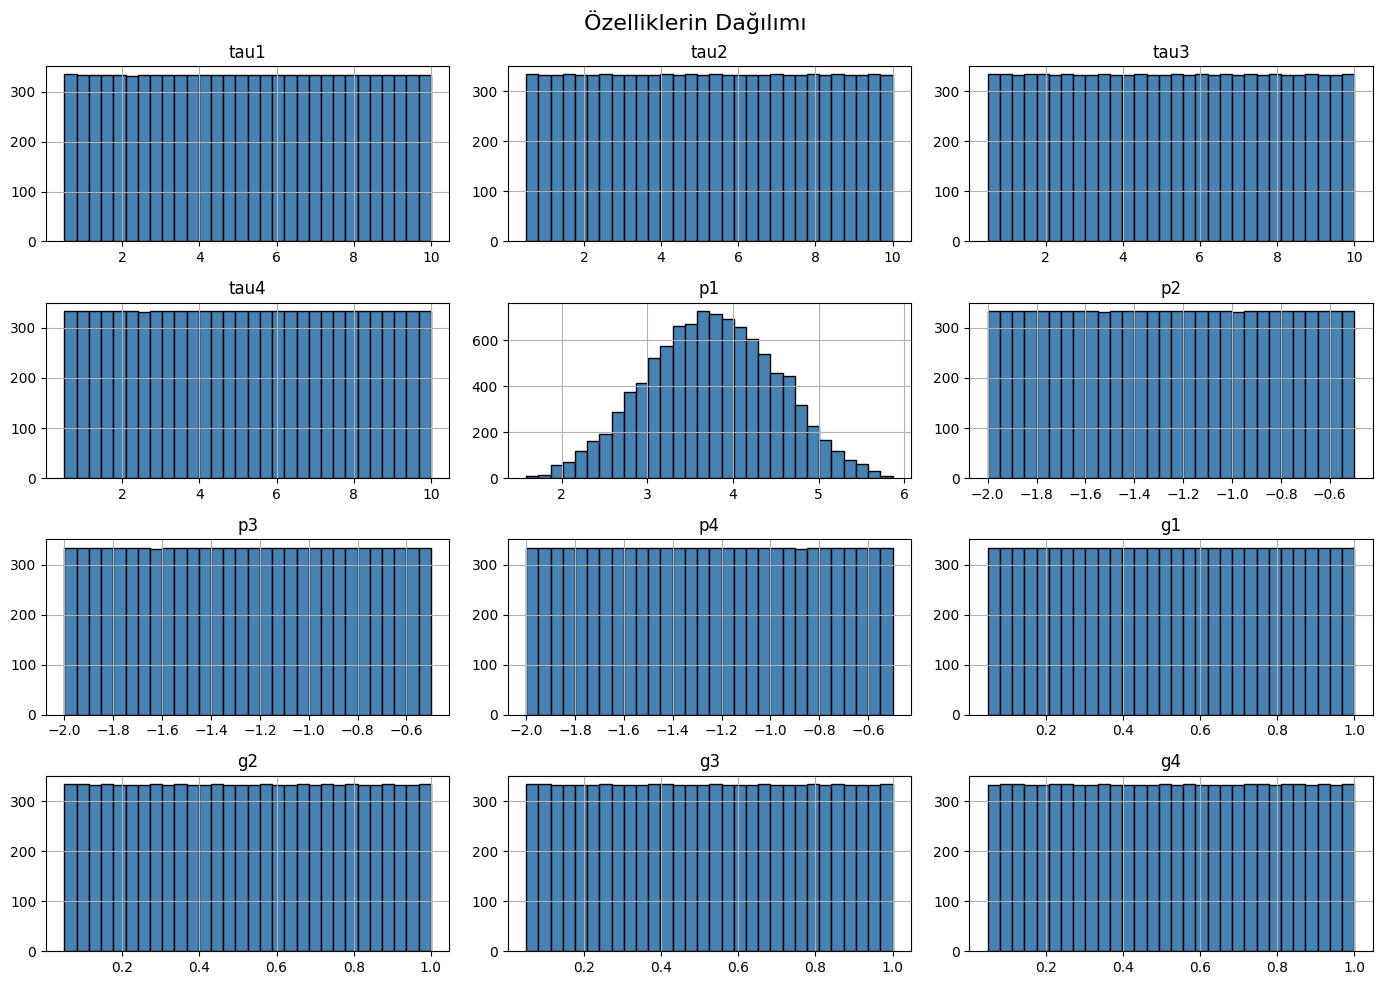

In [18]:
# Tüm özelliklerin histogramı
df.hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Özelliklerin Dağılımı', fontsize=16)
plt.tight_layout()
plt.show()

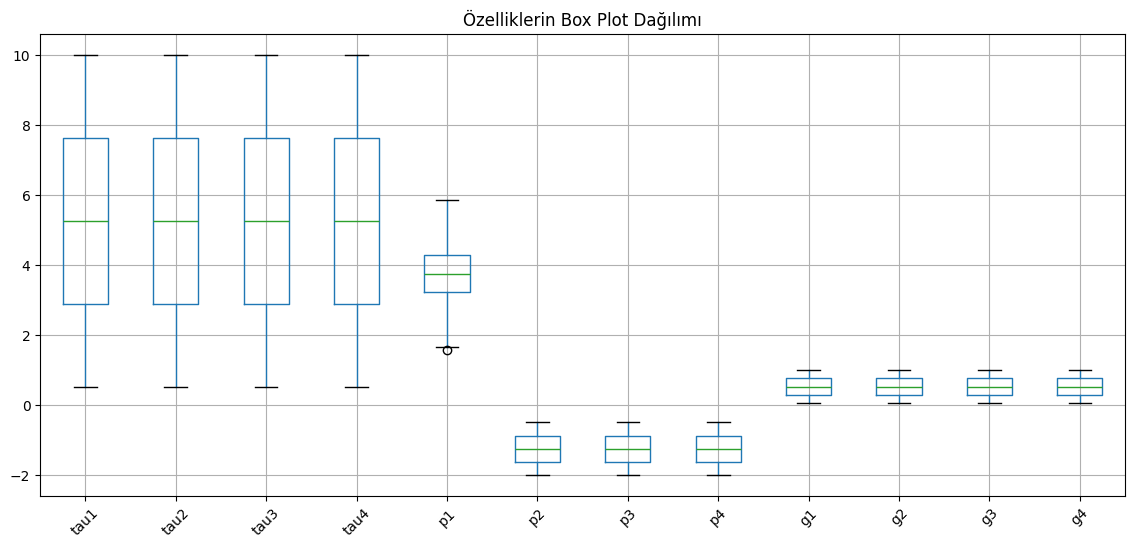

In [44]:
plt.figure(figsize=(14, 6))
df.drop(columns=['stabf']).boxplot()
plt.title('Özelliklerin Box Plot Dağılımı')
plt.xticks(rotation=45)
plt.show()

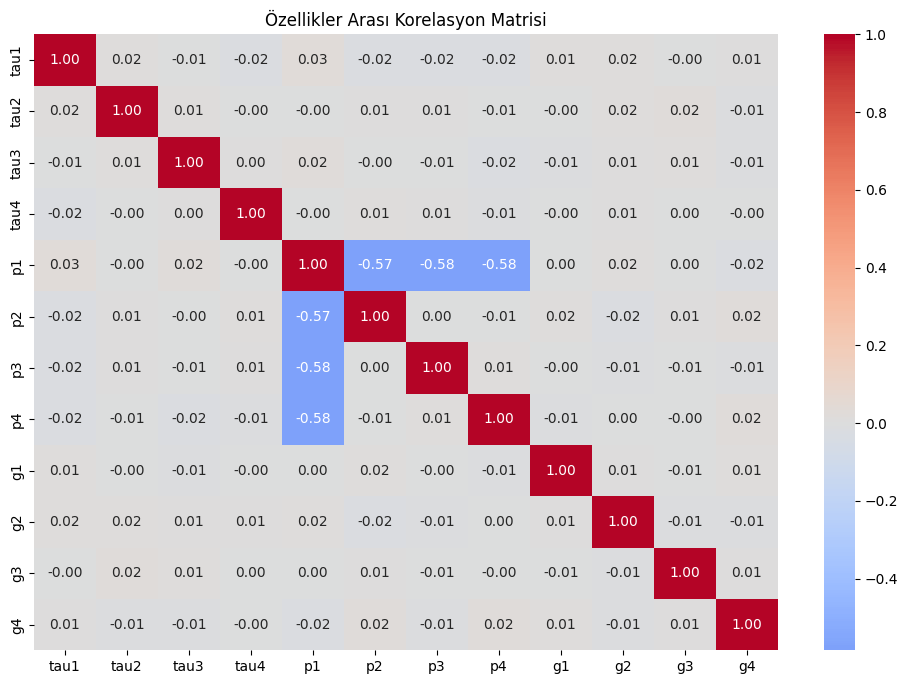

In [45]:
plt.figure(figsize=(12, 8))
correlation = df.drop(columns=['stabf']).corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.show()

In [16]:
# stab sütununu çıkaralım (sayısal hedef, biz stabf kullanacağız)
df = df.drop(columns=['stab'])
print("Kalan sütunlar:", df.columns.tolist())

Kalan sütunlar: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stabf']


In [19]:
from sklearn.preprocessing import LabelEncoder

# stabf sütununu sayıya çevirelim (stable=1, unstable=0)
le = LabelEncoder()
df['stabf'] = le.fit_transform(df['stabf'])

print(df['stabf'].value_counts())
print("Sınıf etiketleri:", le.classes_)

stabf
1    6380
0    3620
Name: count, dtype: int64
Sınıf etiketleri: ['stable' 'unstable']


In [20]:
# X = özellikler, y = hedef
X = df.drop(columns=['stabf'])
y = df['stabf']

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (10000, 12)
y boyutu: (10000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (8000, 12)
Test seti: (2000, 12)


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Modeli oluştur
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli eğit
model.fit(X_train, y_train)

print("Model eğitildi! ✅")

Model eğitildi! ✅


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Tahmin yap
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaylı rapor
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['unstable', 'stable']))

Accuracy: 0.914

Classification Report:
              precision    recall  f1-score   support

    unstable       0.88      0.87      0.87       693
      stable       0.93      0.94      0.93      1307

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Farklı ağaç sayılarını deneyelim
for n in [50, 100, 200, 300]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"n_estimators={n} → Accuracy: {acc:.4f}")

n_estimators=50 → Accuracy: 0.9125
n_estimators=100 → Accuracy: 0.9140
n_estimators=200 → Accuracy: 0.9120
n_estimators=300 → Accuracy: 0.9140


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# class_weight ile dengesizliği düzeltelim
model = RandomForestClassifier(n_estimators=100,
                                class_weight='balanced',
                                random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9085


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Veriyi ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeli kur
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.914


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Farklı derinlik değerlerini deneyelim
for depth in [5, 10, 15, 20, None]:
    model = RandomForestClassifier(n_estimators=100,
                                    max_depth=depth,
                                    random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth={depth} → Accuracy: {acc:.4f}")

max_depth=5 → Accuracy: 0.8570
max_depth=10 → Accuracy: 0.9070
max_depth=15 → Accuracy: 0.9130
max_depth=20 → Accuracy: 0.9150
max_depth=None → Accuracy: 0.9140


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Final modelimiz
model_final = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
model_final.fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

# Metrikler
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['unstable', 'stable']))

Accuracy: 0.915

Classification Report:
              precision    recall  f1-score   support

    unstable       0.88      0.87      0.88       693
      stable       0.93      0.94      0.94      1307

    accuracy                           0.92      2000
   macro avg       0.91      0.90      0.91      2000
weighted avg       0.91      0.92      0.91      2000



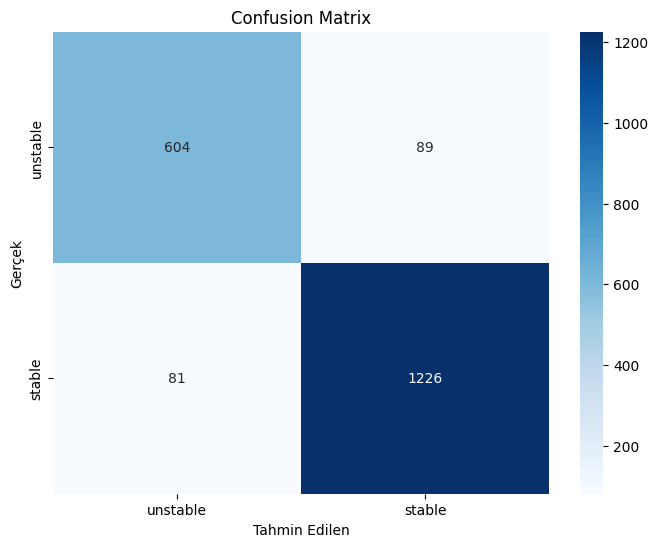

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['unstable', 'stable'],
            yticklabels=['unstable', 'stable'])
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

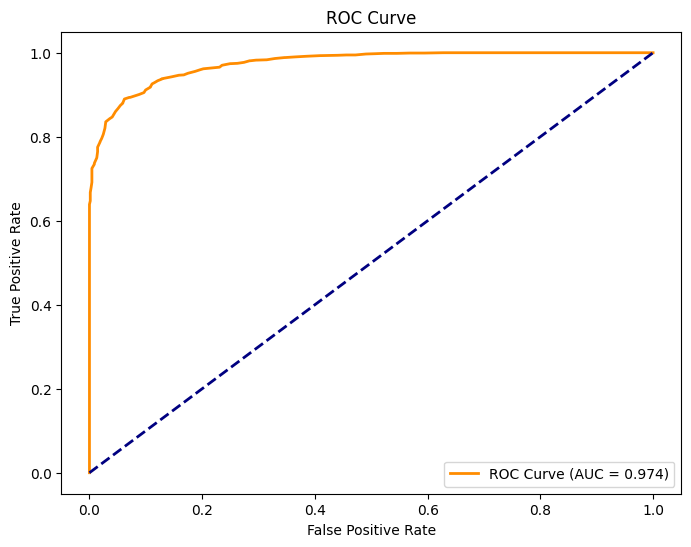

In [37]:
from sklearn.metrics import roc_curve, auc

y_prob = model_final.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

/tmp/ipykernel_12015/3573191882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


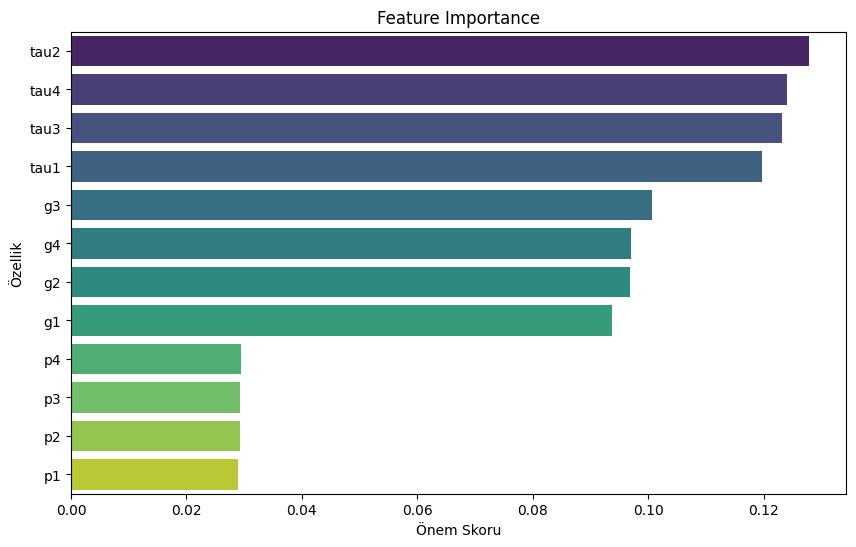

In [38]:
import pandas as pd

feature_importance = pd.Series(model_final.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.show()

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Tüm modeller
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Sonuçları sakla
results = []

for name, model in models.items():
    # Modeli eğit
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Cross validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score': round(f1_score(y_test, y_pred) * 100, 2),
        'CV Mean': round(cv_scores.mean() * 100, 2),
        'CV Std': round(cv_scores.std() * 100, 2)
    })
    print(f"{name} tamamlandı ✅")

import pandas as pd
results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

Decision Tree tamamlandı ✅
KNN tamamlandı ✅
SVM tamamlandı ✅
Random Forest tamamlandı ✅
XGBoost tamamlandı ✅


        Model  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Decision Tree     84.05      88.78   86.53     87.64    83.95    0.85
          KNN     78.90      83.20   84.85     84.02    78.28    0.51
          SVM     88.60      90.35   92.43     91.38    88.66    0.44
Random Forest     91.50      93.23   93.80     93.52    92.05    0.61
      XGBoost     93.50      94.89   95.18     95.03    94.75    0.48


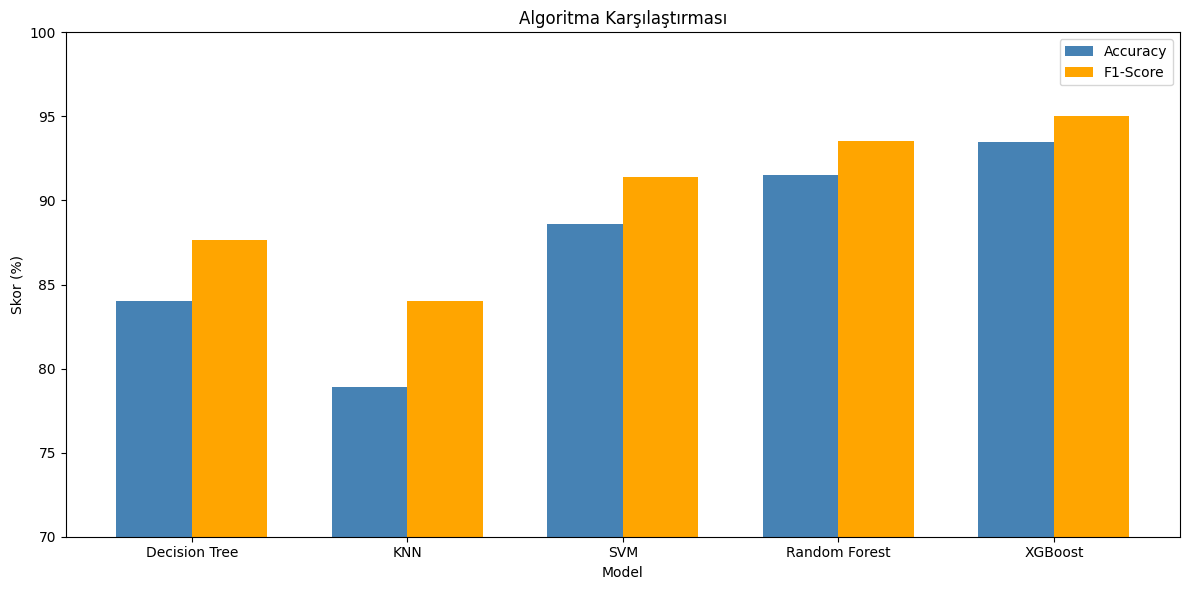

In [47]:
import matplotlib.pyplot as plt
import numpy as np

models_list = results_df['Model']
accuracy = results_df['Accuracy']
f1 = results_df['F1-Score']

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1, width, label='F1-Score', color='orange')

ax.set_xlabel('Model')
ax.set_ylabel('Skor (%)')
ax.set_title('Algoritma Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.legend()
ax.set_ylim(70, 100)

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['unstable', 'stable']))

XGBoost Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

    unstable       0.91      0.90      0.91       693
      stable       0.95      0.95      0.95      1307

    accuracy                           0.94      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.94      0.93      2000



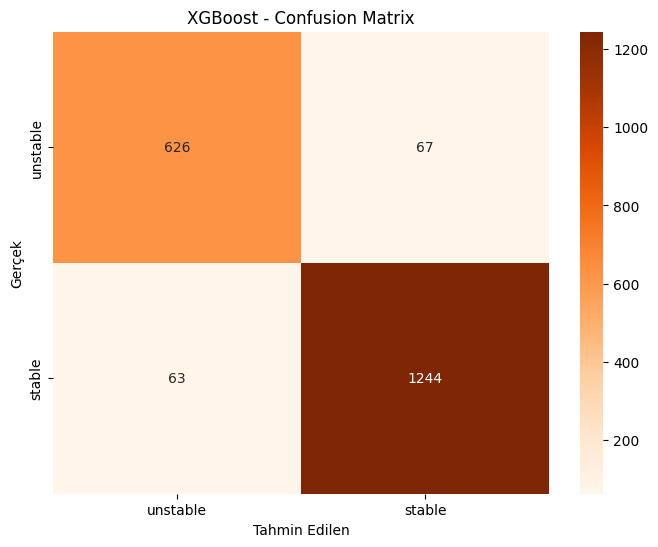

In [41]:
from sklearn.metrics import confusion_matrix

model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['unstable', 'stable'],
            yticklabels=['unstable', 'stable'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

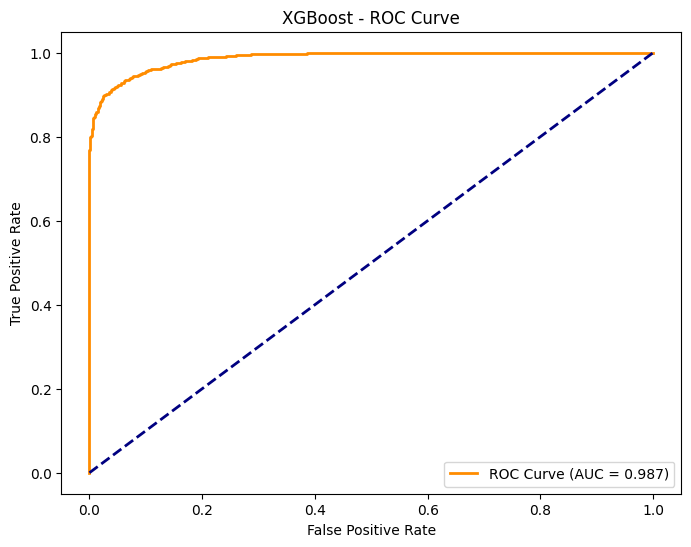

In [42]:
from sklearn.metrics import roc_curve, auc

y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost - ROC Curve')
plt.legend()
plt.show()

/tmp/ipykernel_12015/3491539243.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_xgb.values, y=feature_importance_xgb.index, palette='Oranges_r')


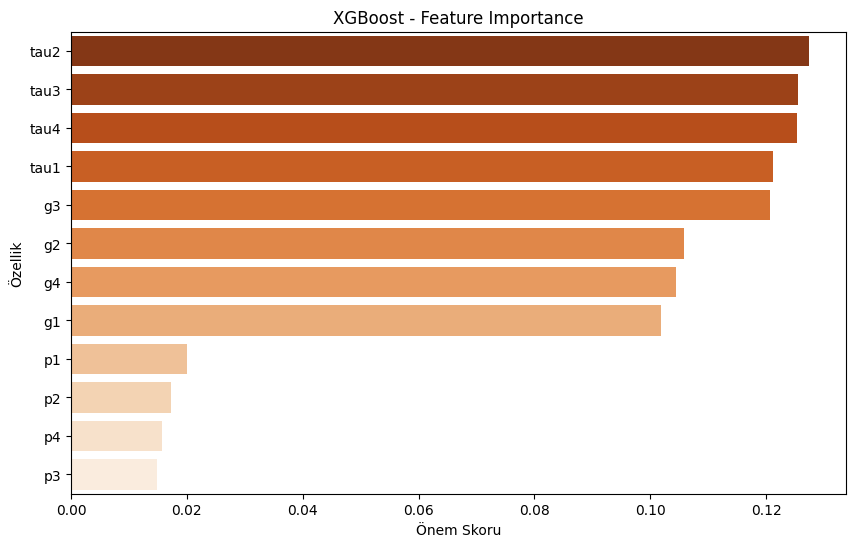

In [43]:
feature_importance_xgb = pd.Series(model_xgb.feature_importances_, index=X.columns)
feature_importance_xgb = feature_importance_xgb.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance_xgb.values, y=feature_importance_xgb.index, palette='Oranges_r')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.show()

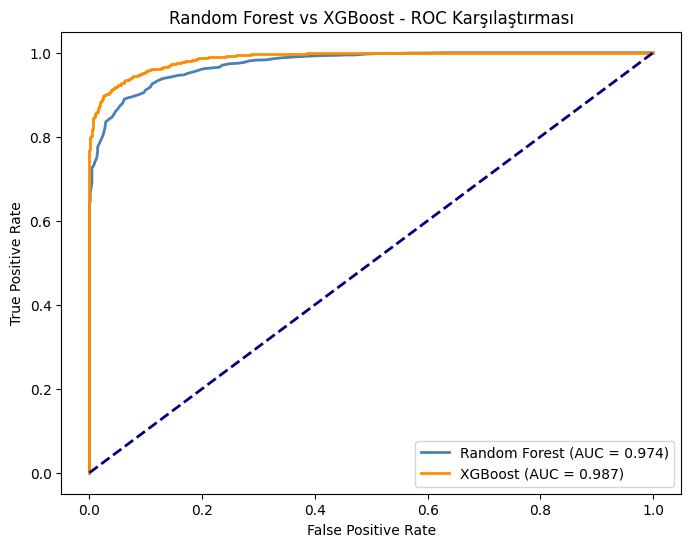

In [46]:
from sklearn.metrics import roc_curve, auc

# Random Forest ROC
y_prob_rf = model_final.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost ROC
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# İkisini aynı grafikte göster
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest vs XGBoost - ROC Karşılaştırması')
plt.legend()
plt.show()